##### The idea of this notebook is to intersect the gene TSSs obtained from DeSeq2 to the chromatin loop anchors and make sense of the biological context of the project

In [1]:
# load both bed files

# pandas intersect (with slop?)

#

In [2]:
import pandas as pd
from pybedtools import BedTool

In [3]:
# All the file loading
# Load TSS
tss_up = BedTool("/usr/users/papantonis1/aman/rnaseq_data/upregulated_transcript_level_TSS.bed_filtered.bed")
tss_down = BedTool("/usr/users/papantonis1/aman/rnaseq_data/downregulated_transcript_level_TSS.bed_filtered.bed")
# loops -mega ctrl + cpi
loops = pd.read_csv("/usr/users/papantonis1/aman/microc_project/loop_calling_premade_hic/jupyter_notes/ml_5_multiclassmodel.csv", sep=",")
#loops_short = loops[['chr1', 'start1', 'end1', 'chr2', 'start2', 'end2']]
loops = pd.DataFrame(loops)
# splitting loops to their anchors
anchor1 = BedTool.from_dataframe(loops[['chr1', 'start1', 'end1']])
anchor2 = BedTool.from_dataframe(loops[['chr2', 'start2', 'end2']])

In [4]:
loops

,Unnamed: 0,chr1,start1,end1,chr2,start2,end2,status,ctrl_signal,rbp1_signal,...,H3K4me3_signal,rad21_signal,GC_mean,GC_diff,E1_anchor1_ctrl,E1_anchor1_rbp1,E1_anchor2_ctrl,E1_anchor2_rbp1,delta_E1_anchor1,delta_E1_anchor2
0,0,chr1,1952500,1957500,chr1,2042500,2047500,shared,NaN,NaN,...,0.188543,0.024018,0.5773,0.0494,NaN,NaN,NaN,NaN,NaN,NaN
1,1,chr1,2202500,2207500,chr1,2382500,2387500,shared,NaN,NaN,...,0.566125,0.063427,0.6135,0.0578,NaN,NaN,NaN,NaN,NaN,NaN
2,2,chr1,2412500,2417500,chr1,2552500,2557500,shared,NaN,NaN,...,0.188543,0.044699,0.6525,0.0102,NaN,NaN,NaN,NaN,NaN,NaN
3,3,chr1,3490000,3495000,chr1,3615000,3620000,shared,NaN,NaN,...,0.188543,0.024769,0.6002,0.0948,NaN,NaN,NaN,NaN,NaN,NaN
4,4,chr1,3565000,3570000,chr1,3615000,3620000,shared,NaN,NaN,...,0.188543,0.042592,0.5949,0.0842,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32272,32272,chrY,10945000,10950000,chrY,11290000,11295000,gained,0.006078,0.006342,...,0.188543,0.026824,0.4545,0.0226,-0.064836,-0.140925,0.270996,0.177009,-0.076090,-0.093987
32273,32273,chrY,10982500,10987500,chrY,11292500,11297500,gained,0.007661,0.005159,...,0.249019,0.130330,0.4609,0.0026,0.120802,-0.100746,0.270996,0.177009,-0.221548,-0.093987
32274,32274,chrY,11292500,11297500,chrY,11722500,11727500,gained,0.001017,0.001021,...,0.241160,0.123878,0.4195,0.0854,0.270996,0.177009,0.409095,0.332632,-0.093987,-0.076464
32275,32275,chrY,11530000,11535000,chrY,11760000,11765000,gained,0.004674,0.006621,...,0.214433,0.112741,0.3788,0.0120,-1.192141,-1.204536,-1.229772,-1.167283,-0.012394,0.062489


In [5]:
# Extend TSS regions for somewhat good intersection
tss_up_slop = tss_up.slop(b=500, genome='hg38')
tss_down_slop = tss_down.slop(b=500, genome='hg38')

In [6]:
tss_df = tss_up.to_dataframe(names=["chrom", "start", "end", "gene_id", "score", "strand"])
print(tss_df.duplicated().sum())  # total row duplicates
print(tss_df.duplicated(subset=["gene_id"]).sum())  # gene-level duplicates

0
0


In [7]:
len(tss_df)

2125

In [8]:
anchor_df = anchor1.to_dataframe(names=["chrom", "start", "end"])
print(anchor_df.duplicated().sum())

8228


In [9]:
anchor_df = anchor2.to_dataframe(names=["chrom", "start", "end"])
print(anchor_df.duplicated().sum())

8555


###### Here the duplicates are (possibly) due to the fact that same anchor can be shared by different distinct loops

In [10]:
tss_df = tss_down.to_dataframe(names=["chrom", "start", "end", "gene_id", "score", "strand"])
print(tss_df.duplicated().sum())  # total row duplicates
print(tss_df.duplicated(subset=["gene_id"]).sum())  # gene-level duplicates

0
0


In [11]:
# tss overlsp with anchor 1 & 2

In [12]:
# function # wa, wb - true. filt. later
def intersect_tss(tss_bed, anchor_bed, num_of_anchor, deg_label):
    df = tss_bed.intersect(anchor_bed, wa=True, wb=True).to_dataframe(names=[
    'tss_chr', 'tss_start', 'tss_end', 'gene_id', 'score', 'strand',
    'anchor_chr', 'anchor_start', 'anchor_end'
    ])
    df['tss_anchor'] = num_of_anchor
    df['deg_class'] = deg_label
    print(df.duplicated().sum())
    print(df.duplicated(subset=["gene_id", "anchor_start", "anchor_end"]).sum())

    return df

# todo: check tss_chr == anchor_chr

In [13]:
up1 = intersect_tss(tss_up_slop, anchor1, 1, 'upregulated_a1')
up2 = intersect_tss(tss_up_slop, anchor2, 2, 'upregulated_a2')
down1 = intersect_tss(tss_down_slop, anchor1, 1, 'downregulated_a1')
down2 = intersect_tss(tss_down_slop, anchor2, 2, 'downregulated_a2')

65
65
66
66
44
44
32
32


In [14]:
all = [up1, up2, down1, down2]
for deg_condition in all:
    print(len(deg_condition))

305
291
150
109


In [15]:
#combine into a single df
tss_anchors_updown = pd.concat([up1, up2, down1, down2], ignore_index=True)
tss_anchors_updown

,tss_chr,tss_start,tss_end,gene_id,score,strand,anchor_chr,anchor_start,anchor_end,tss_anchor,deg_class
0,chr1,37691980,37692981,ENST00000327331.2,0,+,chr1,37692500,37697500,1,upregulated_a1
1,chr1,37692015,37693016,ENST00000373055.6,0,+,chr1,37692500,37697500,1,upregulated_a1
2,chr1,43524686,43525687,ENST00000496043.5,0,+,chr1,43525000,43530000,1,upregulated_a1
3,chr1,43524686,43525687,ENST00000496043.5,0,+,chr1,43525000,43530000,1,upregulated_a1
4,chr1,43524686,43525687,ENST00000496043.5,0,+,chr1,43525000,43530000,1,upregulated_a1
...,...,...,...,...,...,...,...,...,...,...,...
850,chr17,82022820,82023821,ENST00000583383.5,0,+,chr17,82020000,82025000,2,downregulated_a2
851,chr17,82023421,82024422,ENST00000577638.1,0,+,chr17,82020000,82025000,2,downregulated_a2
852,chr22,40346028,40347029,ENST00000639722.1,0,+,chr22,40342500,40347500,2,downregulated_a2
853,chr22,40346028,40347029,ENST00000639722.1,0,+,chr22,40342500,40347500,2,downregulated_a2


In [16]:
tss_anchors_updown = tss_anchors_updown.drop_duplicates(ignore_index=True)
len(tss_anchors_updown)

648

In [17]:
# drop score, strand
#tss_anchors_updown.drop(["score", "strand"], axis=1)


In [18]:
tss_anchors_updown

,tss_chr,tss_start,tss_end,gene_id,score,strand,anchor_chr,anchor_start,anchor_end,tss_anchor,deg_class
0,chr1,37691980,37692981,ENST00000327331.2,0,+,chr1,37692500,37697500,1,upregulated_a1
1,chr1,37692015,37693016,ENST00000373055.6,0,+,chr1,37692500,37697500,1,upregulated_a1
2,chr1,43524686,43525687,ENST00000496043.5,0,+,chr1,43525000,43530000,1,upregulated_a1
3,chr1,43528061,43529062,ENST00000481019.5,0,+,chr1,43525000,43530000,1,upregulated_a1
4,chr1,154404692,154405693,ENST00000622330.5,0,+,chr1,154405000,154410000,1,upregulated_a1
...,...,...,...,...,...,...,...,...,...,...,...
643,chr16,2135397,2136398,ENST00000423118.5,0,-,chr16,2132500,2137500,2,downregulated_a2
644,chr17,82022804,82023805,ENST00000306688.8,0,+,chr17,82020000,82025000,2,downregulated_a2
645,chr17,82022820,82023821,ENST00000583383.5,0,+,chr17,82020000,82025000,2,downregulated_a2
646,chr17,82023421,82024422,ENST00000577638.1,0,+,chr17,82020000,82025000,2,downregulated_a2


In [19]:
#This is a check to make sure that my merged_loop list didn't have duplicates. big scare moment it was. But gave 0 duplicates--yay! I used this file for XGBoost model
cols = [
    "chr1", "start1", "end1",
    "chr2", "start2", "end2",
    "name", "score", "strand1", "strand2"
]  # adjust if fewer or more columns
df = pd.read_csv("/usr/users/papantonis1/aman/microc_project/loop_calling_premade_hic/jupyter_notes/merged_loops.csv", sep="\t", header=None, names=cols)
print(df.duplicated().sum())  # full row dupes
print(df.duplicated(subset=["chr1", "start1", "end1", "chr2", "start2", "end2"]).sum())  # loop duplicates

0
0


In [20]:
# next to deal with the non overlapping anchor at the distal end

In [21]:
# Match to left side of loop (chr1/start1/end1)
match_chr1 = tss_anchors_updown.merge(
    loops,
    left_on=["anchor_chr", "anchor_start", "anchor_end"],
    right_on=["chr1", "start1", "end1"],
    how="inner"
)
match_chr1["distal_chr"] = match_chr1["chr2"]
match_chr1["distal_start"] = match_chr1["start2"]
match_chr1["distal_end"] = match_chr1["end2"]

# Match to right side of loop (chr2/start2/end2)
match_chr2 = tss_anchors_updown.merge(
    loops,
    left_on=["anchor_chr", "anchor_start", "anchor_end"],
    right_on=["chr2", "start2", "end2"],
    how="inner"
)
match_chr2["distal_chr"] = match_chr2["chr1"]
match_chr2["distal_start"] = match_chr2["start1"]
match_chr2["distal_end"] = match_chr2["end1"]

# Combine both matches
final_matched_loops = pd.concat([match_chr1, match_chr2], ignore_index=True)

# Keep shortest loop per TSS-anchor to prevent duplicates
final_matched_loops = final_matched_loops.sort_values("distance").drop_duplicates(
    subset=["gene_id", "anchor_chr", "anchor_start", "anchor_end"],
    keep="first",
    ignore_index=True
)

# Output
final_matched_loops


,tss_chr,tss_start,tss_end,gene_id,score,strand,anchor_chr,anchor_start,anchor_end,tss_anchor,...,GC_diff,E1_anchor1_ctrl,E1_anchor1_rbp1,E1_anchor2_ctrl,E1_anchor2_rbp1,delta_E1_anchor1,delta_E1_anchor2,distal_chr,distal_start,distal_end
0,chr16,69754416,69755417,ENST00000562416.1,0,-,chr16,69750000,69755000,2,...,0.0104,0.445361,0.406969,0.163121,0.147383,-0.038392,-0.015738,chr16,69715000,69720000
1,chr16,69754291,69755292,ENST00000563055.1,0,-,chr16,69750000,69755000,2,...,0.0104,0.445361,0.406969,0.163121,0.147383,-0.038392,-0.015738,chr16,69715000,69720000
2,chr16,69751752,69752753,ENST00000561677.6,0,-,chr16,69750000,69755000,2,...,0.0104,0.445361,0.406969,0.163121,0.147383,-0.038392,-0.015738,chr16,69715000,69720000
3,chr16,69754425,69755426,ENST00000268802.10,0,-,chr16,69750000,69755000,2,...,0.0104,0.445361,0.406969,0.163121,0.147383,-0.038392,-0.015738,chr16,69715000,69720000
4,chr16,69754413,69755414,ENST00000564620.5,0,-,chr16,69750000,69755000,2,...,0.0104,0.445361,0.406969,0.163121,0.147383,-0.038392,-0.015738,chr16,69715000,69720000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
620,chr3,124927270,124928271,ENST00000490147.1,0,-,chr3,124922500,124927500,1,...,0.0216,0.420719,0.511961,0.424292,0.413881,0.091242,-0.010410,chr3,125582500,125587500
621,chr12,68325609,68326610,ENST00000540476.5,0,-,chr12,68322500,68327500,2,...,0.0440,NaN,NaN,NaN,NaN,NaN,NaN,chr12,67352500,67357500
622,chr12,68322711,68323712,ENST00000538454.2,0,-,chr12,68322500,68327500,2,...,0.0440,NaN,NaN,NaN,NaN,NaN,NaN,chr12,67352500,67357500
623,chr12,68322897,68323898,ENST00000536997.1,0,-,chr12,68322500,68327500,2,...,0.0440,NaN,NaN,NaN,NaN,NaN,NaN,chr12,67352500,67357500


In [22]:
len(final_matched_loops)

625

In [23]:
print(final_matched_loops.columns.tolist())


['tss_chr', 'tss_start', 'tss_end', 'gene_id', 'score', 'strand', 'anchor_chr', 'anchor_start', 'anchor_end', 'tss_anchor', 'deg_class', 'Unnamed: 0', 'chr1', 'start1', 'end1', 'chr2', 'start2', 'end2', 'status', 'ctrl_signal', 'rbp1_signal', 'log2FC', 'log2FC_clipped', 'condition', 'distance', 'loop_id', 'comp_switch_A1', 'comp_switch_A2', 'loop_class', 'source', 'CTCF_signal', 'H3K27me3_signal', 'H3K4me3_signal', 'rad21_signal', 'GC_mean', 'GC_diff', 'E1_anchor1_ctrl', 'E1_anchor1_rbp1', 'E1_anchor2_ctrl', 'E1_anchor2_rbp1', 'delta_E1_anchor1', 'delta_E1_anchor2', 'distal_chr', 'distal_start', 'distal_end']


In [24]:
import pandas as pd

# Show all rows
pd.set_option('display.max_rows', None)

# Show all columns
pd.set_option('display.max_columns', None)

# Now display
final_matched_loops[["tss_chr", "tss_start", "tss_end", "distal_chr", "distal_start", "distal_end"]]

,tss_chr,tss_start,tss_end,distal_chr,distal_start,distal_end
0,chr16,69754416,69755417,chr16,69715000,69720000
1,chr16,69754291,69755292,chr16,69715000,69720000
2,chr16,69751752,69752753,chr16,69715000,69720000
3,chr16,69754425,69755426,chr16,69715000,69720000
4,chr16,69754413,69755414,chr16,69715000,69720000
5,chr16,69754423,69755424,chr16,69715000,69720000
6,chrX,152830466,152831467,chrX,152870000,152875000
7,chr3,4979731,4980732,chr3,5020000,5025000
8,chr19,41708125,41709126,chr19,41745000,41750000
9,chr19,41708148,41709149,chr19,41745000,41750000


In [25]:
tss_anchors_updown[["tss_chr", "tss_start", "tss_end"
""]]

,tss_chr,tss_start,tss_end
0,chr1,37691980,37692981
1,chr1,37692015,37693016
2,chr1,43524686,43525687
3,chr1,43528061,43529062
4,chr1,154404692,154405693
5,chr1,154404722,154405723
6,chr1,154404842,154405843
7,chr1,154405114,154406115
8,chr1,21221580,21222581
9,chr1,27103521,27104522


In [26]:
final_matched_loops

,tss_chr,tss_start,tss_end,gene_id,score,strand,anchor_chr,anchor_start,anchor_end,tss_anchor,deg_class,Unnamed: 0,chr1,start1,end1,chr2,start2,end2,status,ctrl_signal,rbp1_signal,log2FC,log2FC_clipped,condition,distance,loop_id,comp_switch_A1,comp_switch_A2,loop_class,source,CTCF_signal,H3K27me3_signal,H3K4me3_signal,rad21_signal,GC_mean,GC_diff,E1_anchor1_ctrl,E1_anchor1_rbp1,E1_anchor2_ctrl,E1_anchor2_rbp1,delta_E1_anchor1,delta_E1_anchor2,distal_chr,distal_start,distal_end
0,chr16,69754416,69755417,ENST00000562416.1,0,-,chr16,69750000,69755000,2,upregulated_a2,22141,chr16,69715000,69720000,chr16,69750000,69755000,gained,0.037667,0.037849,0.006960,0.006960,Mutant loop,35000,22141,stable,stable,intra-TAD,rbp1,6.264811,0.529711,0.227124,0.031918,0.4658,0.0104,0.445361,0.406969,0.163121,0.147383,-0.038392,-0.015738,chr16,69715000,69720000
1,chr16,69754291,69755292,ENST00000563055.1,0,-,chr16,69750000,69755000,2,upregulated_a2,22141,chr16,69715000,69720000,chr16,69750000,69755000,gained,0.037667,0.037849,0.006960,0.006960,Mutant loop,35000,22141,stable,stable,intra-TAD,rbp1,6.264811,0.529711,0.227124,0.031918,0.4658,0.0104,0.445361,0.406969,0.163121,0.147383,-0.038392,-0.015738,chr16,69715000,69720000
2,chr16,69751752,69752753,ENST00000561677.6,0,-,chr16,69750000,69755000,2,upregulated_a2,22141,chr16,69715000,69720000,chr16,69750000,69755000,gained,0.037667,0.037849,0.006960,0.006960,Mutant loop,35000,22141,stable,stable,intra-TAD,rbp1,6.264811,0.529711,0.227124,0.031918,0.4658,0.0104,0.445361,0.406969,0.163121,0.147383,-0.038392,-0.015738,chr16,69715000,69720000
3,chr16,69754425,69755426,ENST00000268802.10,0,-,chr16,69750000,69755000,2,upregulated_a2,22141,chr16,69715000,69720000,chr16,69750000,69755000,gained,0.037667,0.037849,0.006960,0.006960,Mutant loop,35000,22141,stable,stable,intra-TAD,rbp1,6.264811,0.529711,0.227124,0.031918,0.4658,0.0104,0.445361,0.406969,0.163121,0.147383,-0.038392,-0.015738,chr16,69715000,69720000
4,chr16,69754413,69755414,ENST00000564620.5,0,-,chr16,69750000,69755000,2,upregulated_a2,22141,chr16,69715000,69720000,chr16,69750000,69755000,gained,0.037667,0.037849,0.006960,0.006960,Mutant loop,35000,22141,stable,stable,intra-TAD,rbp1,6.264811,0.529711,0.227124,0.031918,0.4658,0.0104,0.445361,0.406969,0.163121,0.147383,-0.038392,-0.015738,chr16,69715000,69720000
5,chr16,69754423,69755424,ENST00000569871.5,0,-,chr16,69750000,69755000,2,upregulated_a2,22141,chr16,69715000,69720000,chr16,69750000,69755000,gained,0.037667,0.037849,0.006960,0.006960,Mutant loop,35000,22141,stable,stable,intra-TAD,rbp1,6.264811,0.529711,0.227124,0.031918,0.4658,0.0104,0.445361,0.406969,0.163121,0.147383,-0.038392,-0.015738,chr16,69715000,69720000
6,chrX,152830466,152831467,ENST00000440023.5,0,+,chrX,152830000,152835000,1,upregulated_a1,15092,chrX,152830000,152835000,chrX,152870000,152875000,lost,0.025911,0.022190,-0.223654,-0.223654,Control loop,40000,15092,stable,stable,intra-TAD,ctrl,1.729350,11.512398,0.188543,0.022016,0.5256,0.0080,-0.491845,-0.482832,-0.203780,-0.253907,0.009013,-0.050127,chrX,152870000,152875000
7,chr3,4979731,4980732,ENST00000460806.1,0,+,chr3,4980000,4985000,1,upregulated_a1,16846,chr3,4980000,4985000,chr3,5020000,5025000,lost,0.034674,0.036021,0.055016,0.055016,Control loop,40000,16846,stable,stable,intra-TAD,ctrl,2.545079,0.188342,0.188543,0.035727,0.4609,0.0166,0.462050,0.470472,0.442050,0.345301,0.008422,-0.096749,chr3,5020000,5025000
8,chr19,41708125,41709126,ENST00000221992.11,0,+,chr19,41705000,41710000,1,upregulated_a1,3210,chr19,41705000,41710000,chr19,41745000,41750000,shared,0.064997,0.049929,-0.380497,-0.380497,shared,40000,3210,stable,stable,intra-TAD,ctrl,4.959643,0.188342,0.243121,0.043134,0.5112,0.0872,-0.135053,-0.098758,-0.349829,-0.416749,0.036295,-0.066920,chr19,41745000,41750000
9,chr19,41708148,41709149,ENST00000615021.4,0,+,chr19,41705000,41710000,1,upregulated_a1,3210,chr19,41705000,41710000,chr19,41745000,41750000,shared,0.064997,0.049929,-0.380497,-0.380497,shared,40000,3210

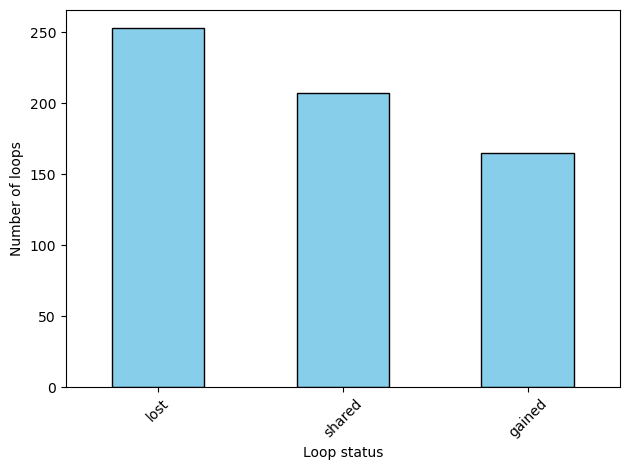

In [27]:
import matplotlib.pyplot as plt

# Count the frequency of each status
status_counts = final_matched_loops['status'].value_counts()

# Plot
status_counts.plot(kind='bar', color='skyblue', edgecolor='black')
#plt.title('Loop Status Distribution')
plt.xlabel('Loop status')
plt.ylabel('Number of loops')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [28]:
# if TSS bed file have only 94 rows, how can it have more than 94 matched loops??

In [29]:
from mygene import MyGeneInfo
import pandas as pd

# Initialize
mg = MyGeneInfo()

# Strip version numbers from Ensembl transcript IDs
ensembl_tx_ids = final_matched_loops['gene_id'].dropna().str.replace(r'\.\d+$', '', regex=True).unique().tolist()

# Query gene symbols using cleaned transcript IDs
gene_info = mg.querymany(ensembl_tx_ids, scopes='ensembltranscript', fields='symbol', species='human')

# Convert to DataFrame and filter
gene_map_df = pd.DataFrame(gene_info)
if 'symbol' in gene_map_df.columns:
    gene_map_df = gene_map_df[['query', 'symbol']].dropna().drop_duplicates()
    gene_map_df.columns = ['gene_id', 'gene_symbol']

    # Merge with version-stripped IDs
    final_matched_loops['gene_id_novers'] = final_matched_loops['gene_id'].str.replace(r'\.\d+$', '', regex=True)
    final_matched_loops = final_matched_loops.merge(gene_map_df, left_on='gene_id_novers', right_on='gene_id', how='left')
    final_matched_loops.drop(columns=['gene_id_novers'], inplace=True)
    final_matched_loops.rename(columns={'gene_symbol': 'gene_symbol', 'query': 'gene_id'}, inplace=True)
else:
    print("No 'symbol' field found in MyGeneInfo results.")

Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed


In [30]:
final_matched_loops

,tss_chr,tss_start,tss_end,gene_id_x,score,strand,anchor_chr,anchor_start,anchor_end,tss_anchor,deg_class,Unnamed: 0,chr1,start1,end1,chr2,start2,end2,status,ctrl_signal,rbp1_signal,log2FC,log2FC_clipped,condition,distance,loop_id,comp_switch_A1,comp_switch_A2,loop_class,source,CTCF_signal,H3K27me3_signal,H3K4me3_signal,rad21_signal,GC_mean,GC_diff,E1_anchor1_ctrl,E1_anchor1_rbp1,E1_anchor2_ctrl,E1_anchor2_rbp1,delta_E1_anchor1,delta_E1_anchor2,distal_chr,distal_start,distal_end,gene_id_y,gene_symbol
0,chr16,69754416,69755417,ENST00000562416.1,0,-,chr16,69750000,69755000,2,upregulated_a2,22141,chr16,69715000,69720000,chr16,69750000,69755000,gained,0.037667,0.037849,0.006960,0.006960,Mutant loop,35000,22141,stable,stable,intra-TAD,rbp1,6.264811,0.529711,0.227124,0.031918,0.4658,0.0104,0.445361,0.406969,0.163121,0.147383,-0.038392,-0.015738,chr16,69715000,69720000,ENST00000562416,NOB1
1,chr16,69754291,69755292,ENST00000563055.1,0,-,chr16,69750000,69755000,2,upregulated_a2,22141,chr16,69715000,69720000,chr16,69750000,69755000,gained,0.037667,0.037849,0.006960,0.006960,Mutant loop,35000,22141,stable,stable,intra-TAD,rbp1,6.264811,0.529711,0.227124,0.031918,0.4658,0.0104,0.445361,0.406969,0.163121,0.147383,-0.038392,-0.015738,chr16,69715000,69720000,ENST00000563055,NOB1
2,chr16,69751752,69752753,ENST00000561677.6,0,-,chr16,69750000,69755000,2,upregulated_a2,22141,chr16,69715000,69720000,chr16,69750000,69755000,gained,0.037667,0.037849,0.006960,0.006960,Mutant loop,35000,22141,stable,stable,intra-TAD,rbp1,6.264811,0.529711,0.227124,0.031918,0.4658,0.0104,0.445361,0.406969,0.163121,0.147383,-0.038392,-0.015738,chr16,69715000,69720000,ENST00000561677,NOB1
3,chr16,69754425,69755426,ENST00000268802.10,0,-,chr16,69750000,69755000,2,upregulated_a2,22141,chr16,69715000,69720000,chr16,69750000,69755000,gained,0.037667,0.037849,0.006960,0.006960,Mutant loop,35000,22141,stable,stable,intra-TAD,rbp1,6.264811,0.529711,0.227124,0.031918,0.4658,0.0104,0.445361,0.406969,0.163121,0.147383,-0.038392,-0.015738,chr16,69715000,69720000,ENST00000268802,NOB1
4,chr16,69754413,69755414,ENST00000564620.5,0,-,chr16,69750000,69755000,2,upregulated_a2,22141,chr16,69715000,69720000,chr16,69750000,69755000,gained,0.037667,0.037849,0.006960,0.006960,Mutant loop,35000,22141,stable,stable,intra-TAD,rbp1,6.264811,0.529711,0.227124,0.031918,0.4658,0.0104,0.445361,0.406969,0.163121,0.147383,-0.038392,-0.015738,chr16,69715000,69720000,ENST00000564620,NOB1
5,chr16,69754423,69755424,ENST00000569871.5,0,-,chr16,69750000,69755000,2,upregulated_a2,22141,chr16,69715000,69720000,chr16,69750000,69755000,gained,0.037667,0.037849,0.006960,0.006960,Mutant loop,35000,22141,stable,stable,intra-TAD,rbp1,6.264811,0.529711,0.227124,0.031918,0.4658,0.0104,0.445361,0.406969,0.163121,0.147383,-0.038392,-0.015738,chr16,69715000,69720000,ENST00000569871,NOB1
6,chrX,152830466,152831467,ENST00000440023.5,0,+,chrX,152830000,152835000,1,upregulated_a1,15092,chrX,152830000,152835000,chrX,152870000,152875000,lost,0.025911,0.022190,-0.223654,-0.223654,Control loop,40000,15092,stable,stable,intra-TAD,ctrl,1.729350,11.512398,0.188543,0.022016,0.5256,0.0080,-0.491845,-0.482832,-0.203780,-0.253907,0.009013,-0.050127,chrX,152870000,152875000,ENST00000440023,NSDHL
7,chr3,4979731,4980732,ENST00000460806.1,0,+,chr3,4980000,4985000,1,upregulated_a1,16846,chr3,4980000,4985000,chr3,5020000,5025000,lost,0.034674,0.036021,0.055016,0.055016,Control loop,40000,16846,stable,stable,intra-TAD,ctrl,2.545079,0.188342,0.188543,0.035727,0.4609,0.0166,0.462050,0.470472,0.442050,0.345301,0.008422,-0.096749,chr3,5020000,5025000,ENST00000460806,BHLHE40
8,chr19,41708125,41709126,ENST00000221992.11,0,+,chr19,41705000,41710000,1,upregulated_a1,3210,chr19,41705000,41710000,chr19,41745000,41750000,shared,0.064997,0.049929,-0.380497,-0.380497,shared,40000,3210,stable,stable,intra-TAD,ctrl,4.959643,0.188342,0.243121,0.043134,0.5112,0.0872,-0.135053,-0.098758,-0.349829,-0.416749,0.036295,-0.066920,chr19,41745000,41750000,ENST0000

In [31]:
final_matched_loops.to_csv("merged_loops_with_genes.tsv", sep="\t", index=False)

In [32]:
genestocheck = final_matched_loops["gene_symbol"].dropna().unique().tolist()
genestocheck

['NOB1',
 'NSDHL',
 'BHLHE40',
 'CEACAM5',
 'LINC00880',
 'BAG3',
 'SEMA3B',
 'TNS4',
 'HEXIM1',
 'PCBP1',
 'TPP1',
 'MMP24OS',
 'SMTN',
 'APLP2',
 'SYT8',
 'BICC1',
 'CTSD',
 'MUC13',
 'IL6R',
 'SEPTIN9',
 'CCDC124',
 'LRRC45',
 'NDRG1',
 'TMC6',
 'CCNE2',
 'LGMN',
 'TBC1D16',
 'CDCP1',
 'JAG2',
 'IGF1R',
 'MAPK12',
 'UVSSA',
 'FAT1',
 'MMD',
 'PDIA4',
 'HLA-C',
 'PCK2',
 'HLA-B',
 'SLC30A1',
 'MDM1',
 'CEACAM19',
 'HRH1',
 'INSR',
 'PTPRF',
 'SLC9A1',
 'PODXL',
 'CDCA8',
 'LGALS3BP',
 'ZFP36L2',
 'CYP2S1',
 'MEI1',
 'VAT1',
 'SORT1',
 'HLA-F',
 'ARHGEF38',
 'CLU',
 'ARHGEF4',
 'S100A11',
 'PKD1',
 'GAA',
 'SIAE',
 'EDC3',
 'COL13A1',
 'ARVCF',
 'ATP8A2',
 'MECOM',
 'PRKCSH',
 'GAR1',
 'TNNI2',
 'GOLGA8A',
 'IL17RD',
 'C15orf39',
 'EFNA5',
 'FHOD1',
 'CREBBP',
 'SLC17A8',
 'CYB5R3',
 'AKR1C3',
 'GTSE1',
 'SNORA80B',
 'LAMC2',
 'PPP1R13B',
 'PTK7',
 'HDAC10',
 'FRMD3',
 'TRHDE',
 'APOBEC3F',
 'CASP6',
 'MAN2C1',
 'SERPINE2',
 'SLC39A10',
 'COPG2',
 'ECE1',
 'PARM1',
 'SUN2',
 'ADGRE5',

In [33]:
len(genestocheck)

102

In [34]:
# to see if any genes have many transcripts
final_matched_loops["gene_symbol"].value_counts()

gene_symbol
APLP2        40
TPP1         37
MECOM        31
MAN2C1       30
SYT8         30
PCK2         28
CLU          24
HLA-B        20
NOB1         17
HLA-F        15
CTSD         14
ARHGEF4      12
SUN2         12
UVSSA         9
CEACAM5       9
HLA-C         9
MMP24OS       9
MDM1          8
AKR1C3        8
SMTN          8
CYB5R3        8
GAR1          8
SEMA3B        8
PRKCSH        8
CCNE2         7
NDRG1         7
SLC39A10      7
PODXL         6
ADGRE5        6
IL17RD        6
PTK7          6
ATP8A2        6
TNNI2         5
SORT1         5
CEACAM19      5
LGALS3BP      5
SIAE          5
CASP6         4
PPP1R13B      4
IL6R          4
APOBEC3F      4
SLC17A8       4
EFNA5         4
IGF1R         4
FAT1          4
MMD           4
SLC9A1        4
PARM1         4
BHLHE40       4
NSDHL         3
INSR          3
SEPTIN9       3
FHOD1         3
CDCP1         3
CCDC124       3
LRRC45        3
BICC1         3
TRHDE         3
PKD1          2
EDC3          2
TMC6          2
C15orf39    

In [35]:
pd.reset_option('display.max_rows')
pd.reset_option('display.max_columns')

In [38]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Fit linear model
model = ols('log2FC ~ C(status)', data=final_matched_loops).fit()

# Run ANOVA
anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)

               sum_sq     df         F    PR(>F)
C(status)   37.193893    2.0  13.94506  0.000001
Residual   829.490931  622.0       NaN       NaN
